In [49]:
import json
from pathlib import Path
from collections import defaultdict

import torch
import pandas as pd


metric = "diffmean"
synthetic = True


# ------------------------
# Config
# ------------------------

if synthetic:
    dm_jsonl = Path(f"pca_64/synthetic_{metric}_by_layer.jsonl")
    emb_dir = Path("../embeddings")              # embeddings on OTHER datasets
    proj_dir = Path("projection_to_synthetic")
    proj_dir.mkdir(exist_ok=True)
else:
    dm_jsonl = Path(f"pca_64/{metric}_by_layer.jsonl")
    emb_dir = Path("../embeddings_synthetic")                   # embeddings on OTHER datasets
    proj_dir = Path("projection_to_real")
    proj_dir.mkdir(exist_ok=True)

# ------------------------
# Load diffmean per layer
# ------------------------

records = []
with dm_jsonl.open("r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        records.append(json.loads(line))

# dm_map: model_short -> list of entries
# each entry: {
#    "primary_benchmark": <benchmark where diffmean was trained>,
#    "primary_column": <column used to compute diffmean>,
#    "diffmean": tensor [L, D],
# }
dm_map = defaultdict(list)

for r in records:
    model_full = r["model"]          # e.g. "meta-llama/Llama-3-8B"
    model_short = model_full.split("/")[-1]
    primary_benchmark = r["benchmark"]   # source / training benchmark
    primary_column = r["column"]         # column used for diffmean
    diffmean = torch.tensor(r["vecs_back"], dtype=torch.float32)  # [L, D]

    entry = {
        "primary_benchmark": primary_benchmark,
        "primary_column": primary_column,
        "diffmean": diffmean,
    }
    dm_map[model_short].append(entry)

print(f"Loaded {len(records)} diffmean entries across "
      f"{len(dm_map)} models from {dm_jsonl}")

# ------------------------
# Iterate over embedding files
# ------------------------

pt_files = sorted(emb_dir.glob("*.pt"))
print(f"Found {len(pt_files)} embedding files in {emb_dir}")

for path in pt_files:
    print(f"\n=== Processing {path} ===")
    data = torch.load(path, map_location="cpu")

    emb_all = data["embeddings"]          # [N_total, L, D]
    model_name = data["model_name"]       # full HF name
    benchmark = data["benchmark"]         # TARGET benchmark (eval)
    column = data["column"]               # column from *embeddings*
    model_short = model_name.split("/")[-1]

    # load the full CSV for this TARGET benchmark
    csv_path = f"../{benchmark}.csv"
    df = pd.read_csv(csv_path)

    print(f"target_benchmark={benchmark}, column={column}, model={model_name}")
    print(f"embeddings shape: {emb_all.shape}, df rows: {len(df)}")

    if model_short not in dm_map:
        print(f"  -> No diffmean entries for model {model_short}, skipping.")
        continue

    # Use id to align DF rows with embedding rows
    ids = df["id"].to_numpy()
    labels = df["binary_label"].to_numpy()
    datasets = df["dataset"].tolist()     # list of split names per row

    ids_t = torch.as_tensor(ids, dtype=torch.long)
    assert ids_t.max().item() < emb_all.shape[0], (
        f"Max id {ids_t.max().item()} >= num embeddings {emb_all.shape[0]}"
    )

    # X: [num_rows, L, D]
    X = emb_all[ids_t]
    num_rows, num_layers, embed_dim = X.shape

    print(f"aligned num_rows={num_rows}, num_layers={num_layers}, embed_dim={embed_dim}")

    eps = 1e-8

    # --------- KEY CHANGE: only match on model_short, not column ----------
    # For this model, project onto *all* diffmean vectors (each from a possibly
    # different primary_benchmark / primary_column).
    for e in dm_map[model_short]:
        primary_benchmark = e["primary_benchmark"]   # where diffmean was trained
        primary_column = e["primary_column"]         # column used for diffmean
        diffmean = e["diffmean"]                     # [L, D]

        assert diffmean.shape == (num_layers, embed_dim), (
            f"Shape mismatch for primary_benchmark={primary_benchmark}, "
            f"primary_column={primary_column}: "
            f"X {X.shape}, diffmean {diffmean.shape}"
        )

        # Normalize ONLY the diffmean vectors: d_hat_l = d_l / ||d_l||
        dm_unit = diffmean / (diffmean.norm(dim=-1, keepdim=True) + eps)  # [L, D]

        # Projection: x_{i,l} ⋅ d_hat_l
        # ( [num_rows,L,D] * [1,L,D] ) -> [num_rows,L,D] -> sum over D -> [num_rows,L]
        proj = (X * dm_unit.unsqueeze(0)).sum(dim=-1)   # [num_rows, L]

        print(
            f"  -> primary_benchmark={primary_benchmark}, "
            f"primary_column={primary_column}, projection shape: {proj.shape}"
        )

        out = {
            "projection": proj,                           # [num_rows, L]
            "id": torch.as_tensor(ids, dtype=torch.long),
            "binary_label": torch.as_tensor(labels),      # same order as rows in df
            "dataset": datasets,                          # list of split names per row
            "benchmark": benchmark,                       # TARGET benchmark (eval)
            "column": column,                             # COLUMN OF EMBEDDINGS (target)
            "primary_benchmark": primary_benchmark,       # SOURCE benchmark (train)
            "primary_column": primary_column,             # SOURCE column (optional)
            "model_name": model_name,
            "metric": metric,
        }

        # Make filename explicit: primary->target
        out_name = (
            f"{primary_benchmark}_TO_{benchmark}_{column}_{primary_column}_"
            f"{model_short}_{metric}.pt"
        )
        out_path = proj_dir / out_name
        torch.save(out, out_path)
        print(f"  -> Saved projections to {out_path}")


Loaded 12 diffmean entries across 6 models from pca_64/synthetic_diffmean_by_layer.jsonl
Found 30 embedding files in ../embeddings

=== Processing ../embeddings/RQ_question_Llama-3.1-8B-Instruct.pt ===
target_benchmark=RQ, column=question, model=meta-llama/Llama-3.1-8B-Instruct
embeddings shape: torch.Size([4997, 33, 4096]), df rows: 4997
aligned num_rows=4997, num_layers=33, embed_dim=4096
  -> primary_benchmark=Hong-1201-v2, primary_column=question, projection shape: torch.Size([4997, 33])
  -> Saved projections to projection_to_synthetic/Hong-1201-v2_TO_RQ_question_question_Llama-3.1-8B-Instruct_diffmean.pt
  -> primary_benchmark=Hong-1201, primary_column=question_with_context, projection shape: torch.Size([4997, 33])
  -> Saved projections to projection_to_synthetic/Hong-1201_TO_RQ_question_question_with_context_Llama-3.1-8B-Instruct_diffmean.pt

=== Processing ../embeddings/RQ_question_Llama-3.3-70B-Instruct.pt ===
target_benchmark=RQ, column=question, model=meta-llama/Llama-3.3-7

# AUROC

In [50]:
import json
from pathlib import Path

import numpy as np
import torch
from sklearn.metrics import roc_auc_score  # make sure scikit-learn is installed

def auc_confint_hanley_mcneil(y_true, y_score, alpha=0.05):
    """
    y_true: 0/1 labels
    y_score: continuous scores
    Returns: auc, lower, upper  (95% CI by default)
    """
    auc = roc_auc_score(y_true, y_score)

    y_true = np.asarray(y_true)
    n_pos = (y_true == 1).sum()
    n_neg = (y_true == 0).sum()

    Q1 = auc / (2.0 - auc)
    Q2 = 2.0 * auc**2 / (1.0 + auc)

    var_auc = (
        auc * (1.0 - auc)
        + (n_pos - 1.0) * (Q1 - auc**2)
        + (n_neg - 1.0) * (Q2 - auc**2)
    ) / (n_pos * n_neg)

    se = np.sqrt(var_auc)
    z = 1.96  # for 95% CI

    lower = auc - z * se
    upper = auc + z * se

    # clamp to [0,1]
    lower = max(0.0, lower)
    upper = min(1.0, upper)

    return float(auc), float(lower), float(upper)

In [51]:
synthetic = True


if synthetic:
    proj_dir = Path("projection_to_synthetic")
    out_path = Path("auroc_project_to_synthetic.jsonl")
else:
    proj_dir = Path("projection_to_real")
    out_path = Path("auroc_project_to_real.jsonl")

pt_files = sorted(proj_dir.glob("*.pt"))
print(f"Found {len(pt_files)} projection files in {proj_dir}")

with open(out_path, "w", encoding="utf-8") as out_f:
    for path in pt_files:
        print(f"\n=== Processing {path} ===")
        data = torch.load(path, map_location="cpu")

        proj = data["projection"]            # [N, L]
        labels = data["binary_label"]        # tensor [N]
        datasets = data["dataset"]           # list of length N
        benchmark = data["benchmark"]
        column = data["column"]
        primary_benchmark = data["primary_benchmark"]
        model_name = data["model_name"]
        metric = data["metric"]
        model_short = model_name.split("/")[-1]

        proj_np = proj.numpy()               # [N, L]
        y_np = labels.numpy()                # [N]

        N, num_layers = proj_np.shape
        print(f"N={N}, num_layers={num_layers}")

        # preserve split order as they first appear in datasets
        seen = set()
        splits = []
        for s in datasets:
            if s not in seen:
                seen.add(s)
                splits.append(s)

        record = {
            "benchmark": benchmark,
            "column": column,
            "model": model_short,
            "primary_benchmark": primary_benchmark,  
            "metric": metric,         
        }

        # test_split = "test"
        # print(f"Computing AUROC on split '{test_split}'")
        # indices = [i for i, s in enumerate(datasets) if s == test_split]
        # y_split = y_np[indices]
        # X_split = proj_np[indices]        # [n_split, L]
        y_split = y_np
        X_split = proj_np        # [n_split, L]

        aurocs = []
        aurocs_ci = []
        for layer_idx in range(num_layers):
            scores = X_split[:, layer_idx]
            try:
                auc, lo, hi = auc_confint_hanley_mcneil(y_split, scores)
            except ValueError:
                # happens if y_split is all 0s or all 1s
                auc, lo, hi = None, None, None
            aurocs.append(auc)
            aurocs_ci.append([lo, hi])

        # e.g. record["train"] = [auroc_layer0, ...]
        #      record["train_ci"] = [[lo0, hi0], [lo1, hi1], ...]
        record['auroc'] = aurocs
        record['auroc_ci'] = aurocs_ci

        out_f.write(json.dumps(record) + "\n")
        out_f.flush()
        print(f"Wrote AUROC record for {benchmark}/{column} ({model_short})")

print(f"\nAll done. AUROCs saved to {out_path}")


Found 160 projection files in projection_to_synthetic

=== Processing projection_to_synthetic/Hong-1201-v2_TO_RQ_question_question_Llama-3.1-8B-Instruct_diffmean.pt ===
N=4997, num_layers=33
Wrote AUROC record for RQ/question (Llama-3.1-8B-Instruct)

=== Processing projection_to_synthetic/Hong-1201-v2_TO_RQ_question_question_Llama-3.1-8B-Instruct_hinge.pt ===
N=4997, num_layers=33
Wrote AUROC record for RQ/question (Llama-3.1-8B-Instruct)

=== Processing projection_to_synthetic/Hong-1201-v2_TO_RQ_question_question_Llama-3.1-8B-Instruct_logistic.pt ===
N=4997, num_layers=33
Wrote AUROC record for RQ/question (Llama-3.1-8B-Instruct)

=== Processing projection_to_synthetic/Hong-1201-v2_TO_RQ_question_question_Llama-3.3-70B-Instruct_diffmean.pt ===
N=4997, num_layers=81
Wrote AUROC record for RQ/question (Llama-3.3-70B-Instruct)

=== Processing projection_to_synthetic/Hong-1201-v2_TO_RQ_question_question_Llama-3.3-70B-Instruct_hinge.pt ===
N=4997, num_layers=81
Wrote AUROC record for RQ/qu

# plot

[0.335703399286939, 0.6613005651870199, 0.648608805305319, 0.6466492483829119, 0.6581752533362364, 0.6785056564062089, 0.6825835306498289, 0.7073047927496394, 0.732647488410491, 0.7316949260176541, 0.7296174327989913, 0.7232307287555907, 0.718971414056192, 0.7204682978163641, 0.7360404249335474, 0.7444592620816664, 0.7316132778125538, 0.7487231127924594, 0.7254579103502709, 0.7231626885846737, 0.7114325631185985, 0.7261609921164122, 0.7072140725217502, 0.7084025075070989, 0.7174654582732312, 0.7178736992987327, 0.729064039408867, 0.7142766422629253, 0.7277032359905288, 0.7189759500675866, 0.7232579448239573, 0.7194794473323718, 0.7185314209509294, 0.7318400783822769, 0.7364804180388103, 0.7456567690898039, 0.7359270246486859, 0.7520933692585436, 0.7535539649275599, 0.7635331899953732, 0.7506645256692885, 0.7558945468071017, 0.7634288617333007, 0.7700106142666632, 0.7593419154668917, 0.756942365439222, 0.7543250868646183, 0.7369340191782563, 0.7091464133757903, 0.6940097433524753, 0.715

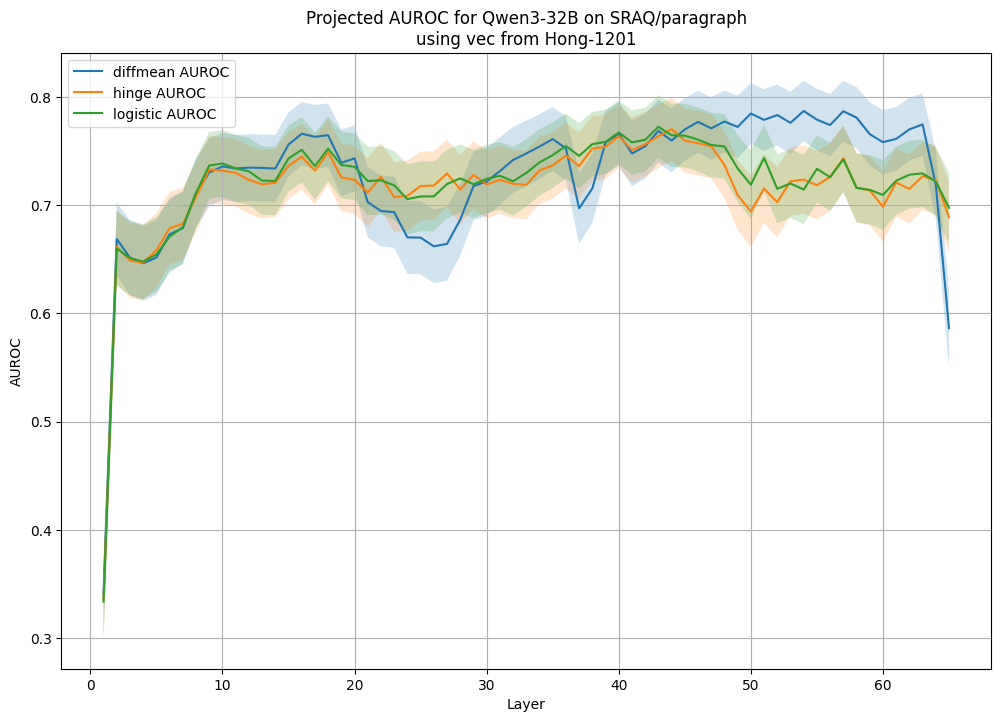

In [3]:
import matplotlib.pyplot as plt
import json
import pathlib
from pathlib import Path
import numpy as np


synthetic = True
model = "Qwen3-32B"
benchmark = "SRAQ"
column = "paragraph"
primary_benchmark = "Hong-1201"




if synthetic:
    auroc_dir = Path("auroc_project_to_synthetic.jsonl")
else:
    auroc_dir = Path("auroc_project_to_real.jsonl")
    
    
auroc = {}
with auroc_dir.open("r", encoding="utf-8") as f:
    for line in f:
        r = json.loads(line)
        if (r["model"] == model and
            r["benchmark"] == benchmark and
            r["column"] == column and
            r["primary_benchmark"] == primary_benchmark):

            metric = r["metric"]
            if metric == 'hinge':
                print(r['auroc'])
            auroc[metric] = {
                "auroc": r["auroc"],
                "auroc_ci": r["auroc_ci"],
            }


plt.figure(figsize=(12,8))
for metric, vals in auroc.items():
    aurocs = vals["auroc"]
    auroc_ci = np.array(vals["auroc_ci"])   # [L, 2]

    layers = np.arange(1, len(aurocs)+1)
    plt.plot(layers, aurocs, label=f"{metric} AUROC")
    plt.fill_between(
        layers,
        auroc_ci[:,0],
        auroc_ci[:,1],
        alpha=0.2
    )
plt.xlabel("Layer")
plt.ylabel("AUROC")
plt.title(f"Projected AUROC for {model} on {benchmark}/{column}\n"
            f"using vec from {primary_benchmark}")
plt.legend()
plt.grid()
plt.show()